In [16]:
print("""This script was written in support of the experiments carried out in:
Nic Ezzell, Lev Barash, Itay Hen, A universal black-box quantum Monte Carlo approach to quantum phase transitions, arXiv:2408.03924v2 (2025).""")

This script was written in support of the experiments carried out in:
Nic Ezzell, Lev Barash, Itay Hen, A universal black-box quantum Monte Carlo approach to quantum phase transitions, arXiv:2408.03924v2 (2025).


In [17]:
import numpy as np
import seaborn as sns
import matplotlib
import matplotlib.pyplot as plt
import glob
import pandas as pd
import sys
import re
import scipy
sys.path.append("../../utils")
from exact_calculations import (prl_gs_chiE, prl_gs_chiF, prl_beta_chiE,
prl_beta_chiX, prl_beta_chiF, prl_gs_fidsus)

matplotlib.style.use("./style.mplstyle")
new_colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728',
              '#9467bd', '#8c564b', '#e377c2', '#7f7f7f',
              '#bcbd22', '#17becf']
plt.rc('text', usetex=True)
plt.rc('text.latex', preamble=r"\usepackage{amsmath}\usepackage{amsfonts}")

In [19]:
fname = "../data/xxz_timing_summary.csv"
cols = ["L", "type", "beta", "wall_time_s"]
df = pd.read_csv(fname, names=cols, skiprows=1)
mapping = {"ES": "ES", "FS": "FS", "nomeas": "Nothing"}
df["type_label"] = df["type"].map(mapping)
df["T"] = 1 / df["beta"]

df.head()

,L,type,beta,wall_time_s,type_label,T
0,10,ES,1.176471,1813.9720,ES,0.85
1,10,ES,1.176471,1824.5430,ES,0.85
2,10,ES,1.176471,1844.5499,ES,0.85
3,10,ES,1.176471,1858.3784,ES,0.85
4,10,ES,1.176471,1858.7818,ES,0.85


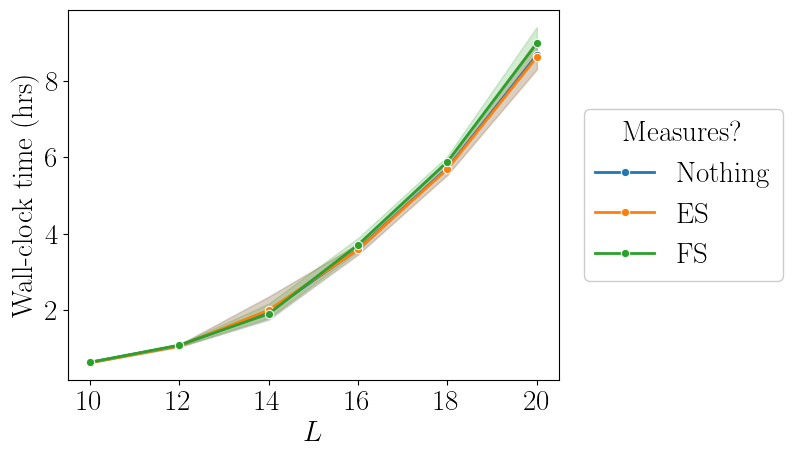

In [27]:
df_T = df[np.isclose(df["beta"], 1.3333, atol=1e-3)]

plt.figure(figsize=(10, 5))  # width, height in inches
lineplot = sns.lineplot(
    x="L",
    y=df_T["wall_time_s"] / 3600,
    hue="type_label",
    hue_order=["Nothing", "ES", "FS"],
    data=df_T,
    markersize=6,
    legend=True,
    marker='o',
    errorbar="pi",
)
lineplot.set_xticks([10, 12, 14, 16, 18, 20])
#lineplot.legend_.set_title(r"Measures?")
lineplot.set_xlabel(r"$L$")
lineplot.set_ylabel("Wall-clock time (hrs)")

# Move legend to the right side, centered vertically
plt.legend(
    title=r"Measures?",
    bbox_to_anchor=(1.05, 0.5),  # x, y anchor in figure coords
    loc="center left",
    borderaxespad=0.,
)

fig = lineplot.get_figure()
fig.tight_layout(rect=[0, 0, 0.85, 1])  # make space on the right for legend


fig = lineplot.get_figure()
fig.savefig("blackbox_paper_figures/Figure6_to_combine_a.pdf", dpi=800, bbox_inches="tight")

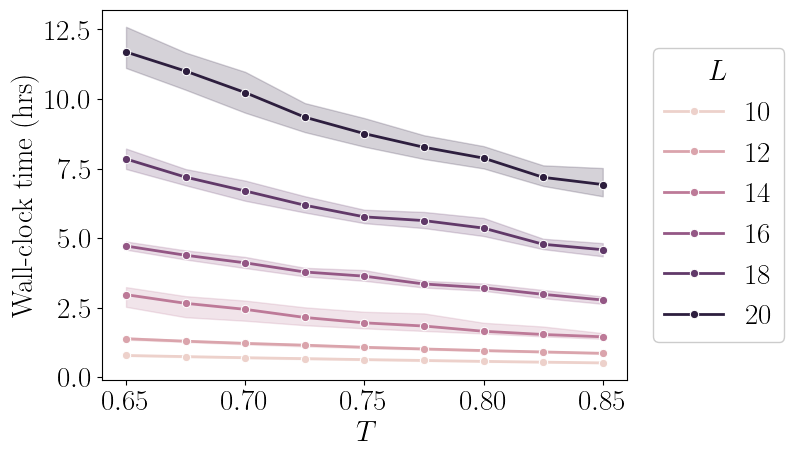

In [28]:
plt.figure(figsize=(10, 5))  # width, height in inches

lineplot = sns.lineplot(
    x="T",
    y=df["wall_time_s"] / 3600,
    hue="L",
    data=df,
    markersize=6,
    legend=True,
    marker='o',
    errorbar="pi"
)
lineplot.legend_.set_title(r"$L$")
lineplot.set_xlabel(r"$T$")
lineplot.set_ylabel("Wall-clock time (hrs)")

# Move legend to the right side, centered vertically
plt.legend(
    title=r"$L$",
    bbox_to_anchor=(1.05, 0.5),  # x, y anchor in figure coords
    loc="center left",
    borderaxespad=0.,
)

fig = lineplot.get_figure()
fig.tight_layout(rect=[0, 0, 0.85, 1])  # make space on the right for legend

# Save the full figure including legend
fig.savefig("blackbox_paper_figures/Figure6_to_combine_b.pdf", dpi=800, bbox_inches="tight")